In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # completely hides all GPUs from TF
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"  # optional, avoids warnings
import numpy as np
import torch
from torch_geometric.data import Data
import cv2
import tensorflow as tf
import tensorflow_hub as hub
from tqdm import tqdm



model = hub.load("https://tfhub.dev/google/movenet/multipose/lightning/1")
movenet = model.signatures['serving_default']

2025-10-06 00:15:27.061135: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-06 00:15:29.160468: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-10-06 00:15:29.160491: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES=""
2025-10-06 00:15:29.160494: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
2025-10-06 00:15:29.160498: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usuall

## video to numpy

In [2]:
# --- Pose detection by movenet ---
def detect_poses(frame):
    input_image = tf.image.resize_with_pad(tf.expand_dims(frame, axis=0), 256, 256)
    input_image = tf.cast(input_image, dtype=tf.int32)
    outputs = movenet(input_image)
    keypoints_with_scores = outputs['output_0'].numpy()  # shape: [1,6,56]
    return keypoints_with_scores[0]  # 6 people max


# --- Feature extraction per frame ---
def process_frame(frame, keypoints_with_scores, prev_people, fps, threshold=0.4):
    h, w, _ = frame.shape
    new_people = []
    features_out = []

    for person in keypoints_with_scores:
        scores = person[2::3]
        if np.sum(scores > threshold) < 5:
            continue

        # Reshape into (17, 3) = (y, x, conf)
        keypoints = np.array(person[:51]).reshape((17, 3))

        # Scale back to pixel coords
        keypoints[:, 0] *= h  # y
        keypoints[:, 1] *= w  # x

        new_people.append(keypoints)

        # Normalize coordinates to [-1, 1]
        y_norm = (keypoints[:, 0] / h) * 2 - 1
        x_norm = (keypoints[:, 1] / w) * 2 - 1
        conf = keypoints[:, 2]

        # Compute velocities
        person_velocities = np.zeros((17, 2))
        if prev_people:
            prev_keypoints = min(
                prev_people, key=lambda pk: np.linalg.norm(pk[:, :2] - keypoints[:, :2])
            )
            dt = 1.0 / fps
            for j, ((y, x, c), (py, px, pc)) in enumerate(zip(keypoints, prev_keypoints)):
                if c > threshold and pc > threshold:
                    vx, vy = (x - px) / dt, (y - py) / dt
                    # Normalize velocity
                    vx /= w
                    vy /= h
                    person_velocities[j] = [vx, vy]

        # Final feature vector per joint
        person_features = np.stack([x_norm, y_norm, conf,
                                    person_velocities[:, 0],
                                    person_velocities[:, 1]], axis=-1)  # (17, 5)

        features_out.append(person_features)

    return features_out, new_people

def video_to_numpy(video_path, max_people=6, threshold=0.4, fps_default=30):
    clip_features = []
    prev_people = []

    if isinstance(video_path, str):
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        frames = []
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)
        cap.release()
    else:
        frames = video_path
        fps = fps_default

    for frame in frames:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        keypoints_with_scores = detect_poses(rgb_frame)

        features_out, prev_people = process_frame(frame, keypoints_with_scores, prev_people, fps, threshold)

        # Pad or crop people to max_people
        while len(features_out) < max_people:
            features_out.append(np.zeros((17, 5), dtype=np.float32))
        features_out = features_out[:max_people]

        clip_features.append(features_out)

    # (T, P, V, F)
    clip_array = np.array(clip_features, dtype=np.float32)
    return clip_array


## numpy to graph

In [3]:
COCO_EDGES = [
    (0, 1), (0, 2),
    (1, 3), (2, 4),
    (0, 5), (0, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (11, 12)
]

In [4]:
def frame_to_graph(frame, edges=COCO_EDGES):
    """
    frame: (P, V, F) tensor (people, joints, features)
    returns: list of Data objects (one graph per person, empty ones skipped)
    """
    people_graphs = []
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    for person in frame:  # (V, F)
        # Skip empty person (all features == 0)
        if torch.all(person == 0):
            continue

        x = person  # node features (17, F)
        data = Data(x=x, edge_index=edge_index)
        people_graphs.append(data)

    return people_graphs

In [5]:
def clip_to_graphs(clip):
    """
    clip: (F, T, V, P)
    returns: list of [graphs per frame]
             len = T, each element = list of Data objects
    """
    graphs_per_frame = []
    F, T, V, P = clip.shape

    for t in range(T):
        frame = clip[:, t, :, :]        # (F, V, P)
        frame = frame.permute(2, 1, 0)  # -> (P, V, F)
        graphs = frame_to_graph(frame)
        graphs_per_frame.append(graphs)

    return graphs_per_frame


## the model itself

In [6]:
def predict_clip(model, npy_path):
    if isinstance(npy_path, str):
        clip = np.load(npy_path)
    else:
        clip = npy_path
    clip = torch.tensor(clip, dtype=torch.float32).permute(3, 0, 2, 1)
    graph_seq = clip_to_graphs(clip)
    with torch.no_grad():
        output = model([graph_seq])
        prob = torch.softmax(output, dim=1)
        pred = torch.argmax(prob, dim=1).item()
    return pred, prob.cpu().numpy()


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class STGCN(nn.Module):
    def __init__(self, in_channels=5, hidden_channels=64, num_classes=2, dropout=0.3):
        super(STGCN, self).__init__()
        self.gcn1 = GCNConv(in_channels, hidden_channels)
        self.gcn2 = GCNConv(hidden_channels, hidden_channels)
        self.lstm = nn.LSTM(hidden_channels, hidden_channels, batch_first=True)
        self.fc = nn.Linear(hidden_channels, num_classes)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_channels)

    def forward(self, batch_graph_seqs):
        """
        batch_graph_seqs: list of [graph_seq] (one per video)
        """
        batch_embs = []

        for graph_seq in batch_graph_seqs:  # loop over videos
            frame_embs = []

            for graphs in graph_seq:  # loop over frames
                if len(graphs) == 0:
                    frame_embs.append(torch.zeros(1, self.gcn1.out_channels, device=self.fc.weight.device))
                    continue

                person_embs = []
                for g in graphs:
                    x = g.x.to(self.fc.weight.device)
                    edge_index = g.edge_index.to(self.fc.weight.device)
                    h = F.relu(self.gcn1(x, edge_index))
                    h = F.relu(self.gcn2(h, edge_index))
                    h = global_mean_pool(h, torch.zeros(h.size(0), dtype=torch.long, device=h.device))
                    person_embs.append(h)

                frame_emb = torch.mean(torch.stack(person_embs), dim=0)
                frame_embs.append(frame_emb)

            frame_embs = torch.cat(frame_embs, dim=0).unsqueeze(0)  # (1, T, C)
            frame_embs = self.layer_norm(frame_embs)
            _, (h_n, _) = self.lstm(frame_embs)
            video_emb = h_n[-1]
            batch_embs.append(video_emb)

        batch_embs = torch.cat(batch_embs, dim=0)
        out = self.fc(self.dropout(batch_embs))
        return out


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
model = STGCN(num_classes=2).to(device)

In [10]:
model.load_state_dict(torch.load("best_stgcn_model.pt", map_location=device))
model.eval()

STGCN(
  (gcn1): GCNConv(5, 64)
  (gcn2): GCNConv(64, 64)
  (lstm): LSTM(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
)

In [11]:
num= 3
path = fr"data/violent/cam2/{num}"
data = video_to_numpy(path+'.mp4')
np.save('test_'+path,data)

KeyboardInterrupt: 

In [ ]:
path = fr"transformed_data/violent/cam1/{num}.npy"
pred, prob = predict_clip(model, path)
print("Prediction:", pred)
print("Probabilities:", prob)

In [ ]:
path = fr"test_data/violent/cam2/{num}.npy"
pred, prob = predict_clip(model, path)
print("Prediction:", pred)
print("Probabilities:", prob)

In [12]:
WINDOW_SEC = 1         # prediction window
FPS = 30               # your videos are 30 FPS
CLIP_LEN = WINDOW_SEC * FPS

In [13]:
from collections import deque
import matplotlib.pyplot as plt
import time

In [14]:
def run_realtime_video(source=0):
    cap = cv2.VideoCapture(source)
    fps = cap.get(cv2.CAP_PROP_FPS) or FPS
    print(f"[INFO] Source FPS: {fps}")

    frame_buffer = deque(maxlen=int(WINDOW_SEC * fps))
    prob_history = deque(maxlen=120)  # keep last ~2 minutes
    start_time = time.time()

    # Live plot setup
    plt.ion()
    fig, ax = plt.subplots(figsize=(5, 3))
    line, = ax.plot([], [], lw=2)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 60)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Violence probability")
    ax.grid(True)

    last_pred_time = 0
    current_prob = 0.0
    pred_label = "Analyzing..."

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_buffer.append(frame.copy())

        # Predict every 1 second
        if time.time() - last_pred_time >= WINDOW_SEC and len(frame_buffer) == frame_buffer.maxlen:
            last_pred_time = time.time()

            # Convert buffer → numpy clip (video_to_numpy handles per-frame pose features)
            frames_np = np.array(frame_buffer)
            npy_clip = video_to_numpy(frames_np)

            pred, prob = predict_clip(model, npy_clip)
            current_prob = float(prob[0, 1])
            pred_label = "VIOLENT" if pred == 1 else "NON-VIOLENT"

            prob_history.append((time.time() - start_time, current_prob))

        # --- Visualization ---
        color = (0, 0, 255) if current_prob > 0.5 else (0, 255, 0)
        cv2.putText(frame, f"{pred_label} ({current_prob:.2f})",
                    (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.1, color, 3)
        cv2.imshow("Violence Detection", frame)

        # --- Update plot ---
        if len(prob_history) > 1:
            t, p = zip(*prob_history)
            line.set_xdata(t)
            line.set_ydata(p)
            ax.set_xlim(max(0, t[-1] - 60), t[-1])
            fig.canvas.draw()
            fig.canvas.flush_events()

        # Exit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    plt.ioff()
    plt.show()

[INFO] Source FPS: 30.0


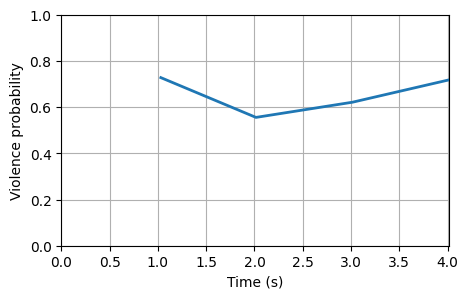

In [15]:
run_realtime_video(fr"data/violent/cam1/6.mp4")

In [ ]:
import threading

In [ ]:
WINDOW_SEC = 1
FPS = 30

frame_buffer = deque(maxlen=int(WINDOW_SEC * FPS))
latest_prob = 0.0
latest_label = "Analyzing..."
buffer_lock = threading.Lock()
prob_history = deque(maxlen=120)
start_time = time.time()

def prediction_thread():
    global latest_prob, latest_label
    while True:
        time.sleep(WINDOW_SEC * 0.5)  # check twice per window
        with buffer_lock:
            if len(frame_buffer) < frame_buffer.maxlen:
                continue
            frames_copy = np.array(frame_buffer)  # copy buffer

        # Run your existing functions
        npy_clip = video_to_numpy(frames_copy)
        pred, prob = predict_clip(model, npy_clip)

        latest_prob = float(prob[0, 1])
        latest_label = "VIOLENT" if pred == 1 else "NON-VIOLENT"
        prob_history.append((time.time() - start_time, latest_prob))